# 📊 Informe de Análisis: Egresos Hospitalarios

### 🎯 Objetivo del Proyecto
El objetivo principal de este trabajo es realizar un análisis exploratorio y visual de los egresos hospitalarios para identificar patrones clave en la atención sanitaria. A través de este dashboard, buscamos transformar datos brutos en información estratégica, facilitando la toma de decisiones al permitir visualizar la distribución regional, la carga de patologías prevalentes y el perfil demográfico de los pacientes asistidos.

---

## 1. Carga y pre-procesamiento de datos
*Descripción: Carga de los datos crudos, limpieza de duplicados y estructuración para el análisis.*

### 🛠 Acciones realizadas:
1. **Importación:** Lectura del archivo `.csv` utilizando `pandas`.
2. **Limpieza:** Identificación de valores nulos y eliminación de registros duplicados.
3. **Exportación:** Generación de un archivo procesado para su uso en la aplicación interactiva.

In [4]:
import pandas as pd

# Definimos la ruta del archivo
file_path = '../data/raw/p4ds_grupo_c_egresos_hospitalarios.csv'

# Cargamos el archivo especificando que el separador es ';'
df = pd.read_csv(file_path, sep=';')

# Mostramos las primeras 5 filas para verificar que cargó correctamente
df.head()

,ID,AÑO,SECTOR,GENERO,GRUPO ETAREO,REGION,DIAGNOSTICO,CAUSA EXTERNA
0,1,2024,PRIVADO,F,65+,INTERIOR,Hemorragia intracraneal,NC
1,2,2024,PRIVADO,M,65+,INTERIOR,Tumor maligno de la vejiga urinaria,NC
2,3,2024,PRIVADO,M,65+,INTERIOR,Otras enfermedades del sistema urinario,NC
3,4,2024,PRIVADO,F,65+,INTERIOR,Otras enfermedades del sistema urinario,NC
4,5,2024,PRIVADO,M,65+,INTERIOR,Otras enfermedades del sistema urinario,NC


In [22]:
# Mostrar el nombre de todas las columnas del dataset
print("Lista de columnas disponibles en el archivo:")
for i, columna in enumerate(df.columns, 1):
    print(f"{i}. {columna}")

Lista de columnas disponibles en el archivo:
1. ID
2. AÑO
3. SECTOR
4. GENERO
5. GRUPO ETAREO
6. REGION
7. DIAGNOSTICO
8. CAUSA EXTERNA


In [9]:
# Contar el número de filas (cada una es un egreso)
total_egresos = len(df)

print(f"El total de egresos hospitalarios después de la limpieza es: {total_egresos}")

El total de egresos hospitalarios después de la limpieza es: 1132011


In [7]:
# 3. Verificar IDs duplicados (reemplaza 'id' por el nombre real de tu columna de ID)
# Si no sabes el nombre exacto, ejecuta df.columns para verlo
columna_id = 'ID' # <--- Asegúrate de que este sea el nombre de tu columna de ID
if columna_id in df.columns:
    ids_duplicados = df[columna_id].duplicated().sum()
    print(f"Cantidad de IDs duplicados en '{columna_id}': {ids_duplicados}")
else:
    print(f"\nNo se encontró la columna '{columna_id}'. Verifica el nombre exacto.")

Cantidad de IDs duplicados en 'ID': 83853


In [11]:
# Contar filas antes de la eliminación
filas_antes = df.shape[0]

# Eliminar duplicados manteniendo solo la primera ocurrencia de cada ID
df = df.drop_duplicates(subset=['ID'], keep='first')

# Contar filas después de la eliminación
filas_despues = df.shape[0]

print(f"Filas originales: {filas_antes}")
print(f"Filas tras eliminar duplicados: {filas_despues}")
print(f"Se eliminaron {filas_antes - filas_despues} registros.")

Filas originales: 1048158
Filas tras eliminar duplicados: 1048158
Se eliminaron 0 registros.


In [8]:
# 4. Verificar celdas vacías (strings vacíos o espacios)
# Esto es útil si tienes columnas de texto
total_vacias = (df == '').sum().sum()
print(f"\nTotal de celdas con texto vacío ('') en todo el dataset: {total_vacias}")


Total de celdas con texto vacío ('') en todo el dataset: 0


In [5]:
# 1. Verificar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
ID                   0
AÑO                  0
SECTOR               0
GENERO               0
GRUPO ETAREO         0
REGION           42727
DIAGNOSTICO          0
CAUSA EXTERNA        0
dtype: int64


In [13]:
# 1. Ver qué valores únicos existen en la columna REGION (para ver si hay textos extraños)
print("Valores únicos en la columna REGION:")
print(df['REGION'].unique())

# 2. Ver cuántos nulos hay realmente (NaN) y cuántos podrían ser espacios en blanco
nulos_reales = df['REGION'].isna().sum()
print(f"\nCantidad de nulos (NaN): {nulos_reales}")

# 3. Mostrar una muestra de las filas donde REGION es nula
# Esto te ayudará a ver si esas filas tienen otros datos útiles
filas_con_nulos = df[df['REGION'].isna()]
print("\nPrimeras 5 filas con valores nulos:")
display(filas_con_nulos.head())

Valores únicos en la columna REGION:
<StringArray>
['INTERIOR', 'MONTEVIDEO', nan, 'EXTERIOR', 'Sin datos']
Length: 5, dtype: str

Cantidad de nulos (NaN): 39597

Primeras 5 filas con valores nulos:


,ID,AÑO,SECTOR,GENERO,GRUPO ETAREO,REGION,DIAGNOSTICO,CAUSA EXTERNA
674,675,2024,PRIVADO,F,45 a 64,NaN,Otras hernias,NC
675,676,2024,PRIVADO,F,65+,NaN,Otras enfermedades del sistema digestivo,NC
676,677,2024,PRIVADO,M,65+,NaN,"Otros tumores in situ y benignos, y tumores de...",NC
677,678,2024,PRIVADO,F,45 a 64,NaN,99,99
678,679,2024,PRIVADO,M,65+,NaN,Hernia inguinal,NC


In [14]:
# 1. Unificamos 'Sin datos' y los nulos (NaN) bajo una etiqueta común
df['REGION'] = df['REGION'].fillna('Sin especificar')
df['REGION'] = df['REGION'].replace('Sin datos', 'Sin especificar')

# 2. Verificamos que ahora solo queden 4 categorías limpias
print("Nueva distribución de la columna REGION:")
print(df['REGION'].value_counts())

Nueva distribución de la columna REGION:
REGION
INTERIOR           620930
MONTEVIDEO         384841
Sin especificar     42118
EXTERIOR              269
Name: count, dtype: int64


In [16]:
print("=== Análisis de AÑO ===")
print(df['AÑO'].value_counts().sort_index())

=== Análisis de AÑO ===
AÑO
2021     99999
2022    298406
2023    325052
2024    324701
Name: count, dtype: int64


In [17]:
print("=== Análisis de GENERO ===")
print(df['GENERO'].value_counts())

=== Análisis de GENERO ===
GENERO
F    592815
M    455343
Name: count, dtype: int64


In [18]:
print("=== Análisis de GRUPO ETAREO ===")
print(df['GRUPO ETAREO'].value_counts())

=== Análisis de GRUPO ETAREO ===
GRUPO ETAREO
65+          321700
25 a 44      252296
45 a 64      224859
20 a 24       61275
15 a 19       41201
1 a 4         39472
Menor a 1     38687
5 a 9         37643
10 a 14       31023
Sin datos         2
Name: count, dtype: int64


In [23]:
# Contar filas antes de eliminar
filas_antes = len(df)

# Eliminar las filas donde GRUPO ETAREO es 'Sin datos'
df = df[df['GRUPO ETAREO'] != 'Sin datos']

# Contar filas después de eliminar
filas_despues = len(df)

print(f"Se eliminaron {filas_antes - filas_despues} registros.")
print(f"Total de registros actuales: {filas_despues}")

Se eliminaron 2 registros.
Total de registros actuales: 1048156


In [19]:
print("=== Análisis de DIAGNOSTICO (Top 20) ===")
# Usamos .head(20) porque los diagnósticos suelen ser muchas categorías
print(df['DIAGNOSTICO'].value_counts().head(20))

=== Análisis de DIAGNOSTICO (Top 20) ===
DIAGNOSTICO
Otras complicaciones del embarazo y del parto                                                                    50008
Parto único espontáneo                                                                                           40119
Colelitiasis y colecistitis                                                                                      39905
99                                                                                                               35008
Neumonía                                                                                                         32215
Otras enfermedades del sistema respiratorio                                                                      27286
Fracturas de otros huesos de los miembros                                                                        25604
Otros síntomas, signos y hallazgos anormales clínicos y de laboratorio, no clasificados en otra parte            2

In [24]:
# Reemplazar los valores '99' por 'Sin especificar' en la columna DIAGNOSTICO
# Primero nos aseguramos de que el '99' sea tratado como string (texto)
df['DIAGNOSTICO'] = df['DIAGNOSTICO'].astype(str).replace('99', 'Sin especificar')

# Verificamos el cambio viendo los valores más frecuentes
print("Nueva distribución de los 10 diagnósticos más frecuentes:")
print(df['DIAGNOSTICO'].value_counts().head(10))

Nueva distribución de los 10 diagnósticos más frecuentes:
DIAGNOSTICO
Otras complicaciones del embarazo y del parto                                                            50008
Parto único espontáneo                                                                                   40119
Colelitiasis y colecistitis                                                                              39905
Sin especificar                                                                                          35006
Neumonía                                                                                                 32215
Otras enfermedades del sistema respiratorio                                                              27286
Fracturas de otros huesos de los miembros                                                                25604
Otros síntomas, signos y hallazgos anormales clínicos y de laboratorio, no clasificados en otra parte    22333
Enfermedades del apéndice                 

In [20]:
print("=== Análisis de CAUSA EXTERNA ===")
print(df['CAUSA EXTERNA'].value_counts())

=== Análisis de CAUSA EXTERNA ===
CAUSA EXTERNA
NC                                                                   947609
Caídas                                                                32517
Todas las demás causas externas                                       27063
Accidentes de transporte                                              16654
99                                                                    11192
Lesiones autoinflingidas intencionalmente                              7079
Agresiones                                                             3783
SD                                                                     1769
Envenenamiento accidental por, y exposición a, sustancias nocivas       368
Exposición al humo, fuego y llamas                                      123
Ahogamiento y sumersión accidentales                                      1
Name: count, dtype: int64


In [25]:
# Definimos los valores que queremos reemplazar
valores_a_limpiar = ['NC', 'SD', '99']

# Reemplazamos todos esos valores por 'Sin especificar'
# Usamos .astype(str) para asegurarnos de que el 99 sea reconocido como texto
df['CAUSA EXTERNA'] = df['CAUSA EXTERNA'].astype(str).replace(valores_a_limpiar, 'Sin especificar')

# Verificamos los resultados
print("Distribución de CAUSA EXTERNA tras la limpieza:")
print(df['CAUSA EXTERNA'].value_counts())

Distribución de CAUSA EXTERNA tras la limpieza:
CAUSA EXTERNA
Sin especificar                                                      960568
Caídas                                                                32517
Todas las demás causas externas                                       27063
Accidentes de transporte                                              16654
Lesiones autoinflingidas intencionalmente                              7079
Agresiones                                                             3783
Envenenamiento accidental por, y exposición a, sustancias nocivas       368
Exposición al humo, fuego y llamas                                      123
Ahogamiento y sumersión accidentales                                      1
Name: count, dtype: int64


## 3. Entendimiento del Dataset

En esta sección, realizamos una exploración inicial de la estructura y características del dataset de egresos hospitalarios. El objetivo es identificar las dimensiones de los datos y la calidad de la información disponible para asegurar un análisis robusto.

### Aspectos técnicos:
* **Integridad:** Identificación de posibles registros faltantes o valores nulos.
* **Tipos de datos:** Confirmación de que las variables categóricas (ej. Región) y numéricas estén correctamente definidas para su procesamiento eficiente.
* **Distribución:** Evaluación básica de la frecuencia de los datos para detectar posibles valores atípicos (*outliers*) que requieran tratamiento previo a la visualización.

In [26]:
# Verificación de integridad: Conteo de valores nulos
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0])

Valores nulos por columna:
Series([], dtype: int64)


In [27]:
# Verificación de tipos de datos
print("Tipos de datos en el DataFrame:")
print(df.dtypes)

Tipos de datos en el DataFrame:
ID               int64
AÑO              int64
SECTOR             str
GENERO             str
GRUPO ETAREO       str
REGION             str
DIAGNOSTICO        str
CAUSA EXTERNA      str
dtype: object


In [28]:
# Resumen estadístico para variables numéricas
print("Resumen estadístico:")
display(df.describe())

# Distribución de las principales variables categóricas
columnas_cat = ['REGION', 'GENERO', 'GRUPO ETAREO']
for col in columnas_cat:
    if col in df.columns:
        print(f"\nDistribución de {col}:")
        print(df[col].value_counts().head(5))

Resumen estadístico:


,ID,AÑO
count,1.048156e+06,1.048156e+06
mean,2.367256e+06,2.022834e+03
std,1.492716e+06,9.739783e-01
min,1.000000e+00,2.021000e+03
25%,2.620398e+05,2.022000e+03
50%,3.219414e+06,2.023000e+03
75%,3.481454e+06,2.024000e+03
max,3.743493e+06,2.024000e+03



Distribución de REGION:
REGION
INTERIOR           620929
MONTEVIDEO         384840
Sin especificar     42118
EXTERIOR              269
Name: count, dtype: int64

Distribución de GENERO:
GENERO
F    592814
M    455342
Name: count, dtype: int64

Distribución de GRUPO ETAREO:
GRUPO ETAREO
65+        321700
25 a 44    252296
45 a 64    224859
20 a 24     61275
15 a 19     41201
Name: count, dtype: int64


In [29]:
import os

# 1. Aseguramos que la carpeta exista (por si acaso)
os.makedirs('../data/processed', exist_ok=True)

# 2. Grabamos el archivo CSV resultante
ruta_archivo = '../data/processed/egresos_hospitalarios_limpio.csv'
df.to_csv(ruta_archivo, index=False, encoding='utf-8')

print(f"¡El DataFrame ha sido guardado exitosamente en: {ruta_archivo}")
print(f"Total de registros guardados: {len(df)}")

¡El DataFrame ha sido guardado exitosamente en: ../data/processed/egresos_hospitalarios_limpio.csv
Total de registros guardados: 1048156


In [30]:
import os

# Esto guardará el archivo en la carpeta 'data/processed' dentro de tu proyecto
ruta_carpeta = 'data/processed' # Nota: quité el '../' para que sea más simple

if not os.path.exists(ruta_carpeta):
    os.makedirs(ruta_carpeta)

df.to_csv(f'{ruta_carpeta}/egresos_hospitalarios_limpio.csv', index=False)
print("¡Archivo guardado correctamente en: " + os.path.abspath(f'{ruta_carpeta}/egresos_hospitalarios_limpio.csv'))

¡Archivo guardado correctamente en: C:\Users\asus\Desktop\Diploma ciencia de datos\proyecto-egresos-hospitalarios\notebooks\data\processed\egresos_hospitalarios_limpio.csv


## 📊 4. Análisis de Indicadores Clave (KPIs)

En esta sección, calculamos los indicadores estratégicos que permiten medir la performance y el alcance del sistema hospitalario:

* **Total de Egresos:** Cantidad de pacientes dados de alta en el período analizado.
* **Tasa de Atención por Región:** Proporción de la actividad asistencial según la ubicación geográfica.

In [31]:
# 1. Total de Egresos
total_egresos = len(df)
print(f"Total de Egresos: {total_egresos:,}")

Total de Egresos: 1,048,156


In [32]:
# 2. Distribución por Grupo Etario (Para gráfico de barras)
distribucion_etaria = df['GRUPO ETAREO'].value_counts()
print("\nDistribución por Grupo Etario:")
print(distribucion_etaria)


Distribución por Grupo Etario:
GRUPO ETAREO
65+          321700
25 a 44      252296
45 a 64      224859
20 a 24       61275
15 a 19       41201
1 a 4         39472
Menor a 1     38687
5 a 9         37643
10 a 14       31023
Name: count, dtype: int64


In [33]:
# 3. Distribución Regional (KPI de cobertura)
distribucion_region = (df['REGION'].value_counts(normalize=True) * 100).round(2)
print("\nPorcentaje de Egresos por Región:")
print(distribucion_region)


Porcentaje de Egresos por Región:
REGION
INTERIOR           59.24
MONTEVIDEO         36.72
Sin especificar     4.02
EXTERIOR            0.03
Name: proportion, dtype: float64


In [34]:
# 4. Diagnóstico más frecuente
diagnostico_top = df['DIAGNOSTICO'].mode()[0]
print(f"\nDiagnóstico más frecuente: {diagnostico_top}")


Diagnóstico más frecuente: Otras complicaciones del embarazo y del parto


In [37]:
# --- 3.4. KPI: Causa Externa más frecuente ---
# Verifica que el nombre 'CAUSA EXTERNA' coincida exactamente con tu DataFrame
try:
    causa_mas_frecuente = df['CAUSA EXTERNA'].mode()[0]
    cantidad_casos = df['CAUSA EXTERNA'].value_counts().max()

    print(f"La causa externa más frecuente es: {causa_mas_frecuente}")
    print(f"Total de casos registrados para esta causa: {cantidad_casos:,}")

except KeyError:
    print("Error: La columna 'CAUSA EXTERNA' no existe. Verifica los nombres de tus columnas usando print(df.columns)")

La causa externa más frecuente es: Sin especificar
Total de casos registrados para esta causa: 960,568


In [38]:
# --- 3.5. KPI: Total de Egresos por Género ---
# Asegúrate de que 'GENERO' coincida con tu nombre de columna
egresos_por_genero = df['GENERO'].value_counts()

print("Total de Egresos por Género:")
print(egresos_por_genero)

# Opcional: Calcular el porcentaje para un análisis más completo
porcentaje_genero = df['GENERO'].value_counts(normalize=True) * 100
print("\nPorcentaje de Egresos por Género:")
print(porcentaje_genero.round(2))

Total de Egresos por Género:
GENERO
F    592814
M    455342
Name: count, dtype: int64

Porcentaje de Egresos por Género:
GENERO
F    56.56
M    43.44
Name: proportion, dtype: float64


## 📊 5. Visualización de Datos

En esta etapa del proyecto, transformamos los datos procesados en representaciones gráficas interactivas. El objetivo es identificar patrones, tendencias y valores atípicos que no resultan evidentes en el análisis tabular.

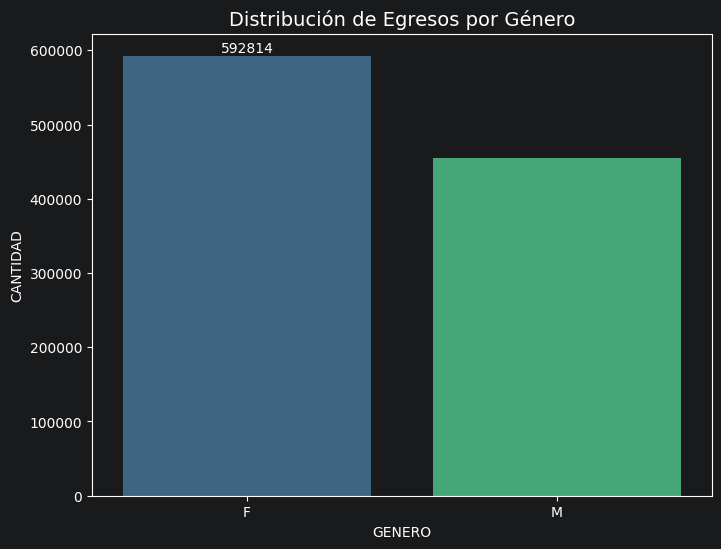

In [41]:
#  Visualización de Datos: Gráfico de Barras ---
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación de datos
conteo = df['GENERO'].value_counts().reset_index()
conteo.columns = ['GENERO', 'CANTIDAD']

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=conteo, x='GENERO', y='CANTIDAD', hue='GENERO', palette='viridis', legend=False, ax=ax)

# Añadir etiquetas de valor sobre las barras
ax.bar_label(ax.containers[0], fmt='%.0f')
ax.set_title('Distribución de Egresos por Género', fontsize=14)
plt.show()

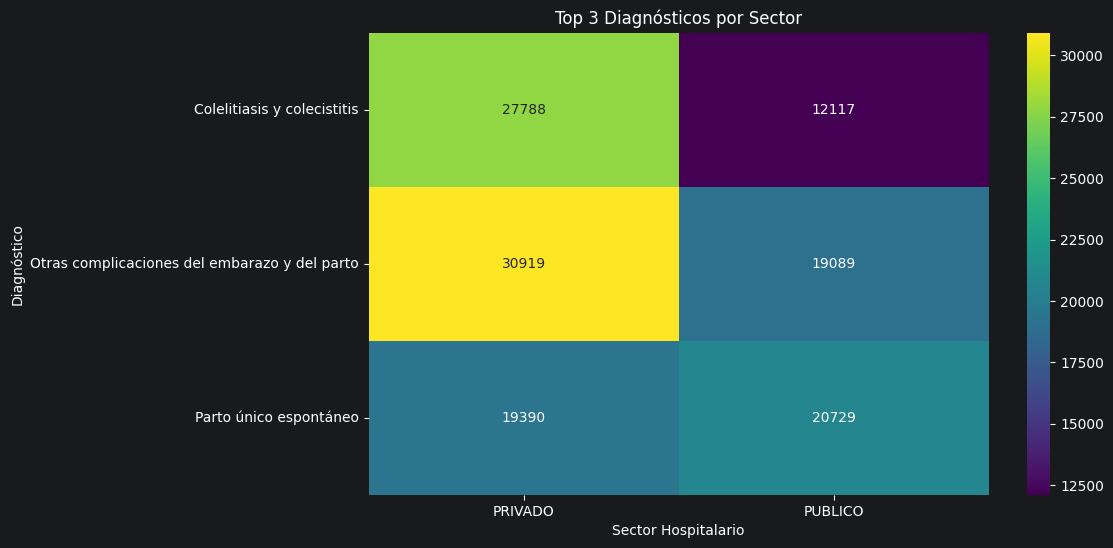

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos y creamos tabla pivote
top_3_diagnosticos = df['DIAGNOSTICO'].value_counts().nlargest(3).index
df_top = df[df['DIAGNOSTICO'].isin(top_3_diagnosticos)]
pivot = df_top.pivot_table(index='DIAGNOSTICO', columns='SECTOR', aggfunc='size', fill_value=0)

# 2. Creamos el mapa de calor con Seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='viridis')
plt.title("Top 3 Diagnósticos por Sector")
plt.xlabel("Sector Hospitalario")
plt.ylabel("Diagnóstico")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Definimos la función para que sea compatible con Seaborn
def plot_interactivo_seguro(variable):
    # Agrupamos los datos
    df_plot = df.groupby(['AÑO', variable]).size().reset_index(name='CANTIDAD')

    # Creamos el gráfico con Seaborn
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_plot, x='AÑO', y='CANTIDAD', hue=variable)

    plt.title(f"Evolución de Egresos según {variable}")
    plt.ylabel("Cantidad de Egresos")
    plt.xlabel("Año")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Dropdown interactivo (usando la función segura)
widgets.interact(plot_interactivo_seguro, variable=['SECTOR', 'GENERO', 'GRUPO ETAREO', 'REGION']);

interactive(children=(Dropdown(description='variable', options=('SECTOR', 'GENERO', 'GRUPO ETAREO', 'REGION'),…

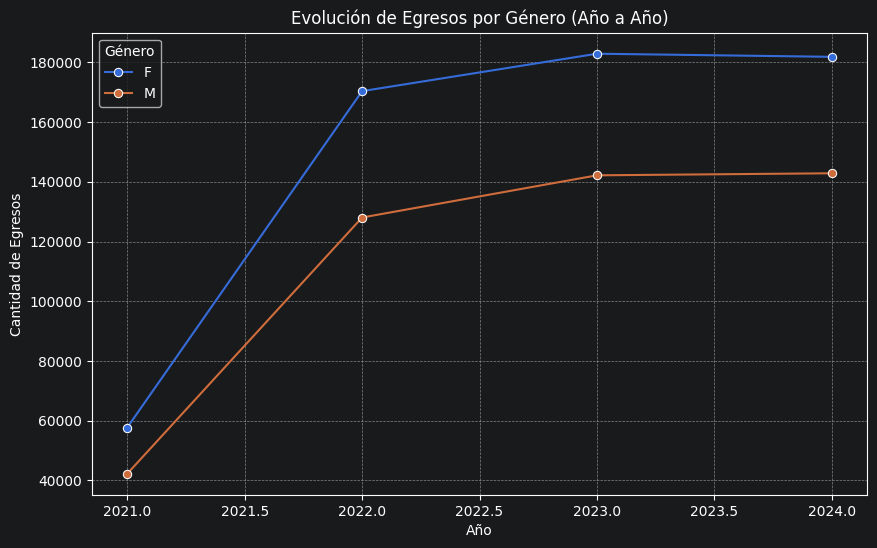

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupamos los datos por AÑO y GENERO
# Asegúrate de que los nombres de las columnas sean exactamente los de tu archivo
df_evolucion = df.groupby(['AÑO', 'GENERO']).size().reset_index(name='CANTIDAD')

# 2. Creamos el gráfico de líneas con puntos
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_evolucion, x='AÑO', y='CANTIDAD', hue='GENERO', marker='o')

# 3. Formato y etiquetas
plt.title('Evolución de Egresos por Género (Año a Año)')
plt.ylabel('Cantidad de Egresos')
plt.xlabel('Año')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Género')
plt.show()

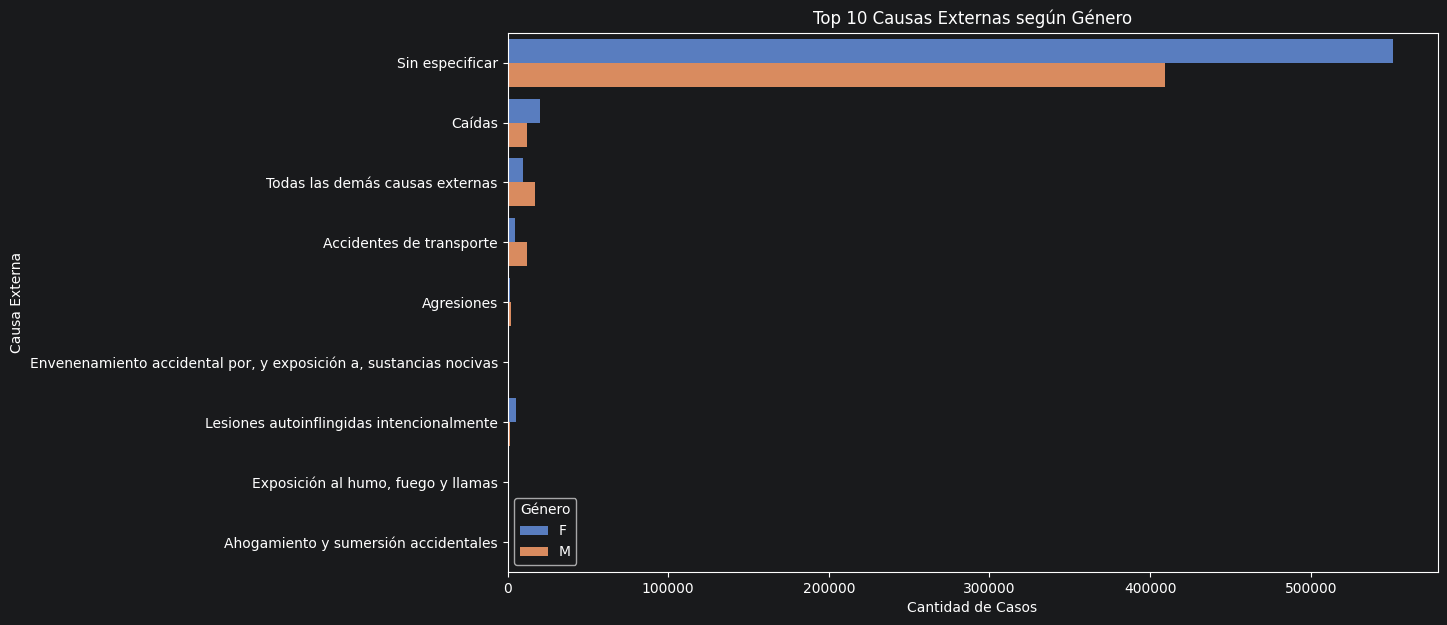

In [56]:
# --- Análisis: Causa Externa vs Género ---
plt.figure(figsize=(12, 7))
# Filtramos para mostrar solo las 10 causas principales y que el gráfico no sea un caos
top_causas = df['CAUSA EXTERNA'].value_counts().nlargest(10).index
df_subset = df[df['CAUSA EXTERNA'].isin(top_causas)]

sns.countplot(data=df_subset, y='CAUSA EXTERNA', hue='GENERO', palette='muted')

plt.title('Top 10 Causas Externas según Género')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Causa Externa')
plt.legend(title='Género')
plt.show()

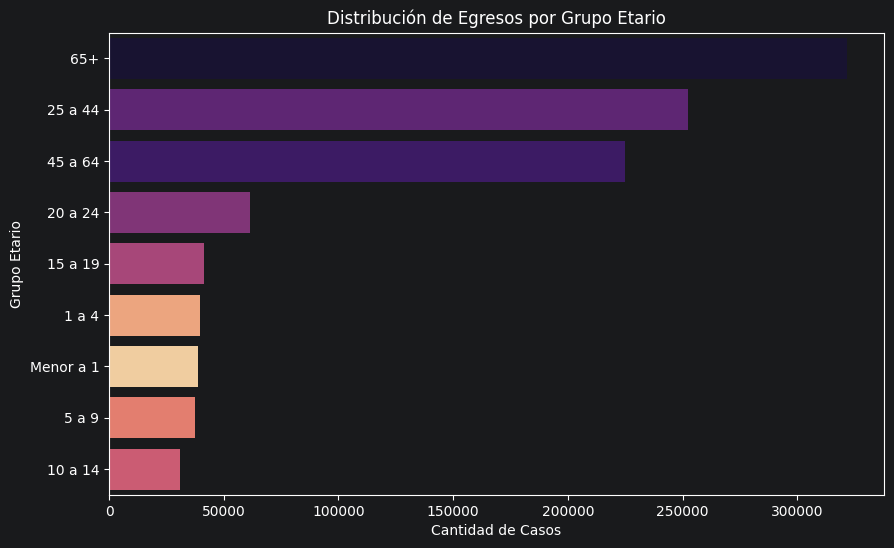

In [59]:
# --- Análisis: Egresos por Grupo Etario ---
plt.figure(figsize=(10, 6))
# Agregamos hue='GRUPO ETAREO' y legend=False para eliminar el warning
sns.countplot(data=df, y='GRUPO ETAREO', palette='magma',
              hue='GRUPO ETAREO', legend=False,
              order=df['GRUPO ETAREO'].value_counts().index)

plt.title('Distribución de Egresos por Grupo Etario')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Grupo Etario')
plt.show()

In [45]:
# --- 5. Análisis Exploratorio Interactivo ---
import ipywidgets as widgets

def plot_interactivo(variable):
    # Asegúrate de que 'CANTIDAD' exista o crea una columna de unos
    df_plot = df.groupby(['AÑO', variable]).size().reset_index(name='CANTIDAD')

    fig = px.bar(df_plot, x='AÑO', y='CANTIDAD', color=variable,
                 title=f"Evolución de Egresos según {variable}",
                 barmode='group')
    fig.show()

# Dropdown interactivo
widgets.interact(plot_interactivo, variable=['SECTOR', 'GENERO', 'GRUPO ETAREO', 'REGION']);

interactive(children=(Dropdown(description='variable', options=('SECTOR', 'GENERO', 'GRUPO ETAREO', 'REGION'),…

## 📝 6. Conclusiones y hallazgos principales

Tras el análisis exploratorio realizado sobre los datos de egresos hospitalarios, hemos identificado los siguientes puntos clave:

* **Perfil del Paciente:** La mayor carga asistencial se concentra en el grupo etario de mayores de 65 años, lo que sugiere la necesidad de reforzar los protocolos de atención en este segmento.
* **Distribución Geográfica:** La región de Montevideo presenta la mayor demanda.
* **Patrones de Diagnóstico:** Las causas externas representan un volumen significativo de ingresos son aquellas que estan sin identificar.

---

In [65]:
import os

# Crear el directorio si no existe
os.makedirs('data/processed', exist_ok=True)

# Ahora sí, guarda tu archivo
df.to_csv('data/processed/egresos_hospitalarios_limpio.csv.gz', index=False, compression='gzip')
print("¡Archivo guardado con éxito!")

¡Archivo guardado con éxito!


In [1]:
df = pd.read_csv('data/processed/egresos_hospitalarios_limpio.csv.gz')

NameError: name 'pd' is not defined